In [1]:
!pip install -U diffusers

## Local Inference on GPU
Model page: https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [ ]:
pip install -U diffusers transformers accelerate

Note: you may need to restart the kernel to use updated packages.


: 

In [ ]:
import torch
from diffusers import DiffusionPipeline

# switch to "mps" for apple devices
pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, device_map="balanced")

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]

There are modules in UNet2DConditionModel that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

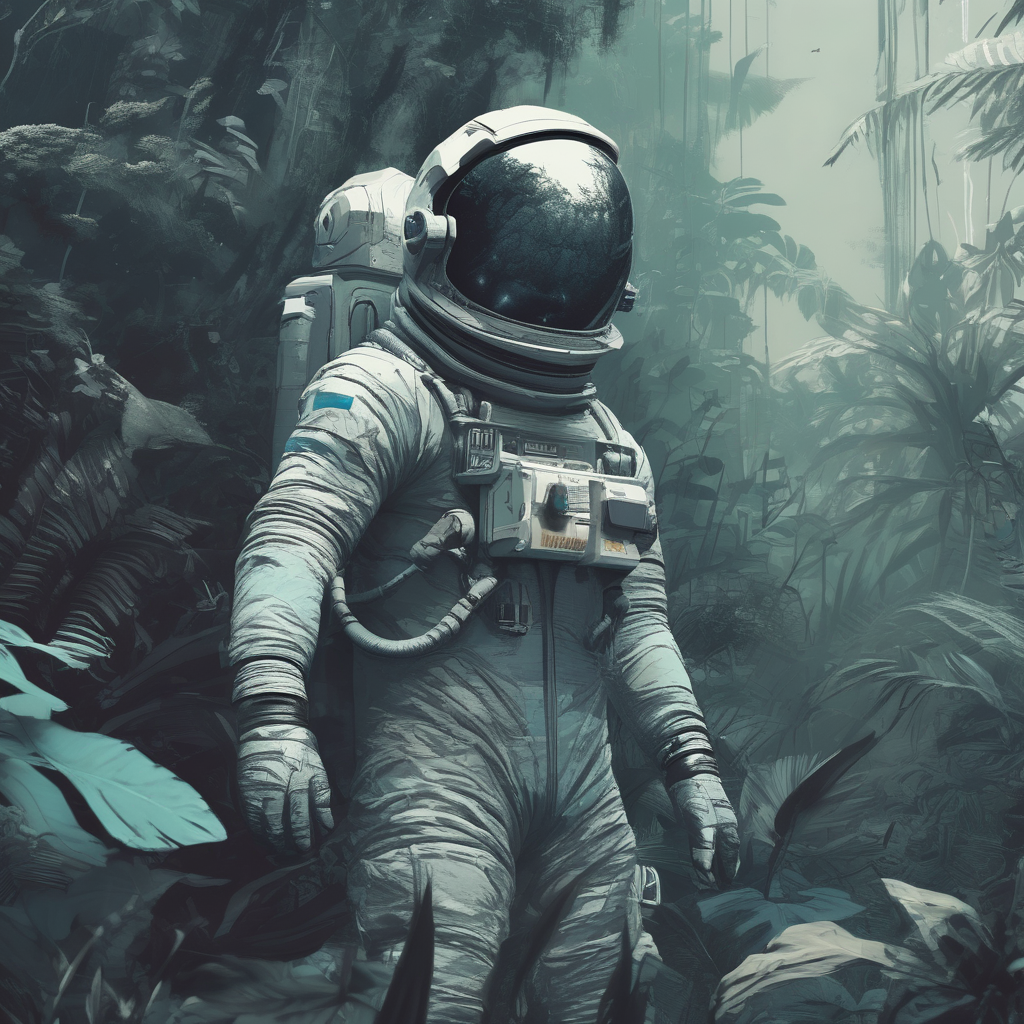

In [ ]:
image

## Remote Inference via Inference Providers
Ensure you have a valid **HF_TOKEN** set in your environment. You can get your token from [your settings page](https://huggingface.co/settings/tokens). Note: running this may incur charges above the free tier.
The following Python example shows how to run the model remotely on HF Inference Providers, automatically selecting an available inference provider for you.
For more information on how to use the Inference Providers, please refer to our [documentation and guides](https://huggingface.co/docs/inference-providers/en/index).

In [ ]:
import os
os.environ['HF_TOKEN'] = 'YOUR_TOKEN_HERE'

In [ ]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"],
)

# output is a PIL.Image object
image = client.text_to_image(
    "Astronaut riding a horse",
    model="stabilityai/stable-diffusion-xl-base-1.0",
)